# **Basic Classififcation Model**

#### Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from tqdm import tqdm
import math
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator


C:\Users\Vish\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Dataset

In [2]:
dataset = [
    (1,"Introduction to NLP"),
    (2,"Basics of PyTorch"),
    (1,"NLP Techniques for Text Classification"),
    (3,"Named Entity Recognition with PyTorch"),
    (3,"Sentiment Analysis using PyTorch"),
    (3,"Machine Translation with PyTorch"),
    (1," NLP Named Entity,Sentiment Analysis,Machine Translation "),
    (1," Machine Translation with NLP "),
    (1," Named Entity vs Sentiment Analysis  NLP "),
    (3,"he painted the car red"),
    (1,"he painted the red car")
    ]

Initiate Tokenizor

In [3]:
tokenizor = get_tokenizer("basic_english")

def yield_token (dataset):
    for id, text in dataset:
        yield tokenizor(text)

#### Build Vocabulary

In [4]:
vocab =  build_vocab_from_iterator(yield_token(dataset), specials=["<unk>"])
vocab.set_default_index(vocab["<unk>"])

In [5]:
vocab["he"]

12

#### Text Pipeline Implementing

This is use for enode the input data

In [6]:
def text_pipeline(input):
    return vocab(tokenizor(input))

In [7]:
def label_pipeline(input):
    return int(input) - 1

## **Section of Zero Padding**


In many PyTorch applications, maintaining consistent batch sizes is essential. Since input sequences often have varying lengths, **zero padding** is used to make them uniform within a batch.

You can achieve this using the `pad_sequence` function. Consider a list of tensors where each tensor represents a sequence with a different length.

The `pad_sequence` function from `torch.nn.utils.rnn` is designed to handle this scenario by padding all sequences to the same length along a specified dimension. This is especially useful in tasks like Natural Language Processing (NLP), where sentences (after tokenization) naturally vary in length.

### How it works:

1. **Input**  
   `pad_sequence` accepts a list of tensors, where each tensor represents a sequence. These sequences can have different lengths.

2. **Padding**  
   The function pads shorter sequences with zeros (or a specified padding value) so that all sequences match the length of the longest sequence in the list.

3. **Output**  
   The result is a single tensor where all sequences are stacked along a specified dimension (default is the first dimension), forming a batch with uniform sequence length.

In [8]:
sequence = [torch.tensor([j for j in range(1, i)]) for i in range(2,10)]
sequence

[tensor([1]),
 tensor([1, 2]),
 tensor([1, 2, 3]),
 tensor([1, 2, 3, 4]),
 tensor([1, 2, 3, 4, 5]),
 tensor([1, 2, 3, 4, 5, 6]),
 tensor([1, 2, 3, 4, 5, 6, 7]),
 tensor([1, 2, 3, 4, 5, 6, 7, 8])]

In [9]:
from torch.nn.utils.rnn import pad_sequence

In [10]:
# we use pad_sequence to get all the tensors to a fixed length
# this will stack the tensors after it convert to same length
padded_sequence = pad_sequence(sequence,batch_first=True, padding_value=0)
padded_sequence

tensor([[1, 0, 0, 0, 0, 0, 0, 0],
        [1, 2, 0, 0, 0, 0, 0, 0],
        [1, 2, 3, 0, 0, 0, 0, 0],
        [1, 2, 3, 4, 0, 0, 0, 0],
        [1, 2, 3, 4, 5, 0, 0, 0],
        [1, 2, 3, 4, 5, 6, 0, 0],
        [1, 2, 3, 4, 5, 6, 7, 0],
        [1, 2, 3, 4, 5, 6, 7, 8]])

## **Positional Encoding**

In [11]:
input_seq = "he painted the car red he painted the red car"

tokens = text_pipeline(input_seq)
tokens

[12, 13, 15, 11, 14, 12, 13, 15, 14, 11]

In [12]:
tokens_tensor = torch.tensor(tokens)
tokens_tensor

tensor([12, 13, 15, 11, 14, 12, 13, 15, 14, 11])

In [13]:
num_dims = 3
vocab_size = len(vocab)

embedding_layer = nn.Embedding(vocab_size,num_dims)

In [14]:
embedd_out = embedding_layer(tokens_tensor)
embedd_out, embedd_out.shape

(tensor([[ 0.1484,  0.6706, -0.3718],
         [-0.4362,  1.8038,  0.9950],
         [ 0.4956, -0.7834, -0.9037],
         [-1.1571, -0.7241,  0.1953],
         [-1.0933,  0.0154, -2.0771],
         [ 0.1484,  0.6706, -0.3718],
         [-0.4362,  1.8038,  0.9950],
         [ 0.4956, -0.7834, -0.9037],
         [-1.0933,  0.0154, -2.0771],
         [-1.1571, -0.7241,  0.1953]], grad_fn=<EmbeddingBackward0>),
 torch.Size([10, 3]))

In [15]:
# for plotting purpose we need to convert this to a numpy array
embedd_out_array = embedd_out.detach().numpy()
embedd_out_array, embedd_out_array.shape

(array([[ 0.14839895,  0.67059416, -0.37183058],
        [-0.43618384,  1.8037953 ,  0.9950459 ],
        [ 0.49556163, -0.78344566, -0.9037056 ],
        [-1.157127  , -0.72414005,  0.19529079],
        [-1.0932915 ,  0.01542953, -2.0771332 ],
        [ 0.14839895,  0.67059416, -0.37183058],
        [-0.43618384,  1.8037953 ,  0.9950459 ],
        [ 0.49556163, -0.78344566, -0.9037056 ],
        [-1.0932915 ,  0.01542953, -2.0771332 ],
        [-1.157127  , -0.72414005,  0.19529079]], dtype=float32),
 (10, 3))

#### **Plot Embedding**

In [16]:
def plot_embedding (embedding_array, name,vocab):
    
    fig = plt.figure()
    ax = fig.add_subplot(111,projection='3d')
    
    #plot the data points
    ax.plot(embedding_array[:,0], embedding_array[:,1],embedding_array[:,2])
    
    # labels for data point
    for j, label in enumerate(name):
        id = vocab.get_stoi()[label]
        ax.text(embedding_array[j,0],embedding_array[j,1],embedding_array[j,2],label)
    
    ax.set_xlabel("X Label")
    ax.set_ylabel("Y Label")
    ax.set_zlabel("Z Label")
    
    plt.show()

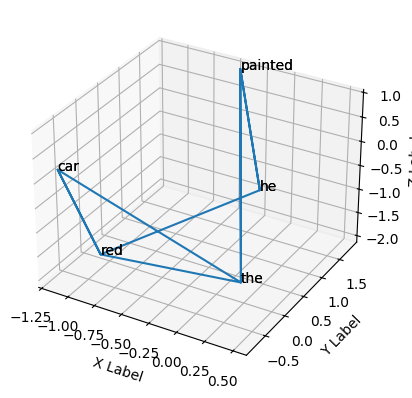

In [17]:
plot_embedding(embedd_out_array,tokenizor(input_seq), vocab)

## **Positioanl Embedding**

In [18]:
class positionalEmbedding(nn.Module):
    
    def __init__(self, max_seq_len,d_model,dropout):
        super().__init__()
        
        self.dropout = nn.Dropout(dropout)
        positions = torch.arange(0,max_seq_len,dtype=torch.float).unsqueeze(1)
        pe = torch.zeros(max_seq_len,d_model)
        
        div_term = torch.exp(
                torch.arange(0,d_model,2).float() *(-math.log(10000.0) /d_model)
                )
        
        pe[:,0::2] = torch.sin(positions * div_term)
        pe[:,1::2] = torch.cos(positions * div_term)
        
        pe = pe.unsqueeze(0)
        self.register_buffer("pe",pe)
        
    def forward(self,word_embedding):
        #word embedding -> [batch_size,seq_len, n_dims]
        seq_len = word_embedding.size(1)
        positional_embedding = word_embedding + self.pe[:,0:seq_len,:]
        
        return self.dropout(positional_embedding)

### What is Self-Attention?

Self-attention is a mechanism that allows each word (or token) in a sentence to interact with every other word, including itself, to determine how important each word is in the context of the sentence.

To achieve this, three types of vectors are created for every token:
- **Query (Q)**
- **Key (K)**
- **Value (V)**

Let’s understand these using a simple analogy.

---

### Search Engine Analogy

#### Query (Q)
Think of the query as what you type into a search engine.

For example:
> "best smartphones"

This represents what you're looking for.

---

#### Key (K)
The search engine has already stored and indexed massive amounts of information from web pages.

- Titles  
- Headings  
- Content  
- Metadata  

All of this stored information acts as **keys**. These keys help the system understand what each piece of content is about.

---

#### Value (V)
Once you enter your query, the search engine compares it with the stored keys to find relevant matches.

The actual results you get — the web pages returned — are the **values**.

---

### Connecting Back to Self-Attention

In self-attention:
- The **query** represents what a word is looking for.
- The **keys** represent what every other word offers.
- The **values** represent the actual information carried by each word.

By comparing queries with keys, the model assigns attention scores and combines the values accordingly — allowing it to understand context and relationships between words effectively.

In [20]:
input = "he painted the car red he painted the red car"
token_indices =text_pipeline(input)
token_indices

[12, 13, 15, 11, 14, 12, 13, 15, 14, 11]

In [23]:
# convert token indices into tensor that the model can process
token_indices = torch.tensor(token_indices)
print(f"token indices: {token_indices}")
print(f"shape:{token_indices.shape}")

token indices: tensor([12, 13, 15, 11, 14, 12, 13, 15, 14, 11])
shape:torch.Size([10])


C:\Users\Vish\AppData\Local\Temp\ipykernel_20280\1030731157.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  token_indices = torch.tensor(token_indices)


In [27]:
d_model = 4
vocab_size = len(vocab)

In [29]:
# convert token indices into embeddings
embedding_layer = nn.Embedding(vocab_size,d_model)
input_embeddings = embedding_layer(token_indices)

In [30]:
print(f"input embeddings: {input_embeddings}")
print(f"shape of input embeddings: {input_embeddings.shape}")

input embeddings: tensor([[-5.2743e-02, -3.3779e-01, -2.9257e-01, -1.6447e-01],
        [ 1.4138e-01,  3.8694e-01, -1.4776e-03,  1.3824e+00],
        [ 1.6145e+00, -5.1251e-01,  7.7445e-02, -1.2298e+00],
        [ 5.8511e-01, -2.2520e+00,  7.1872e-01, -1.2084e-01],
        [ 2.5447e+00, -1.4807e+00,  7.8120e-01,  1.6750e+00],
        [-5.2743e-02, -3.3779e-01, -2.9257e-01, -1.6447e-01],
        [ 1.4138e-01,  3.8694e-01, -1.4776e-03,  1.3824e+00],
        [ 1.6145e+00, -5.1251e-01,  7.7445e-02, -1.2298e+00],
        [ 2.5447e+00, -1.4807e+00,  7.8120e-01,  1.6750e+00],
        [ 5.8511e-01, -2.2520e+00,  7.1872e-01, -1.2084e-01]],
       grad_fn=<EmbeddingBackward0>)
shape of input embeddings: torch.Size([10, 4])


This line of code initializes a Transformer Encoder Layer in PyTorch using the nn.TransformerEncoderLayer class. Let's break down its components:

- `d_model=3`: This parameter specifies the dimensionality of the model's input and output features. In this case, each input and output vector will have a size of 3. You can think of this as the "width" of the model.

- `nhead=1`: It defines the number of attention heads in the multi-head self-attention mechanism. In this case, there is only one attention head, meaning that the model will perform single-head self-attention. In the context of transformers, "n heads" refer to the number of parallel attention mechanisms used to capture diverse patterns and dependencies in the data simultaneously.

- `dim_feedforward=1`: This parameter sets the dimensionality of the feedforward neural network used within the Transformer layer. The feedforward network is responsible for processing the attention output. Here, it has an extremely low dimension of 1, which is unusually small and may not perform well in practice. In practice, this value is typically much larger to capture complex patterns.

- `dropout=0`: Dropout is a regularization technique used to prevent overfitting by randomly setting a fraction of input units to zero during training. A dropout rate of 0 means no dropout will be applied in this layer.


In [25]:
encoder_layer = nn.TransformerEncoderLayer(
    d_model=4,
    nhead=2,
    dim_feedforward= 2,
    dropout=0.3
)

In [31]:
encoder_layer_out = encoder_layer(input_embeddings)
encoder_layer_out

tensor([[-1.5817,  0.6733, -0.1081,  1.0165],
        [-1.0591, -0.3678, -0.2152,  1.6421],
        [ 1.6220, -0.0658, -0.5009, -1.0553],
        [ 0.8525, -1.6268,  0.7915, -0.0172],
        [ 1.1280, -1.5493, -0.1348,  0.5561],
        [ 0.4943, -0.0906, -1.5557,  1.1520],
        [-0.4836, -0.3981, -0.8278,  1.7095],
        [ 0.8075, -1.6928,  0.6554,  0.2298],
        [ 0.9513, -1.6095, -0.0502,  0.7084],
        [ 0.9319, -1.6716,  0.5481,  0.1917]],
       grad_fn=<NativeLayerNormBackward0>)